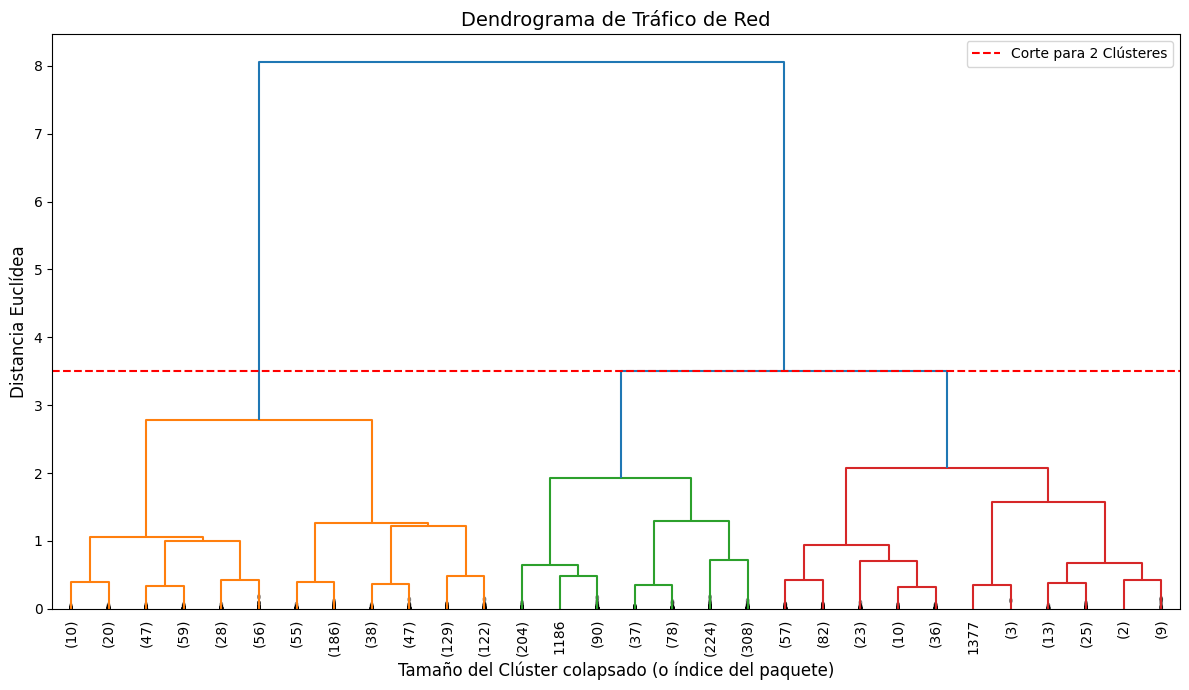


Resumen de la asignación de clústeres:
Cluster_Asignado    1    2
Origen                    
Ligero            472  528
Pesado            325  675


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

archivo_ligero = 'traficoligero.parquet'
archivo_pesado = 'traficopesado.parquet'

df_ligero = pd.read_parquet(archivo_ligero)
df_pesado = pd.read_parquet(archivo_pesado)

cols_interes = ['Length', 'Inter-arrival']

df_ligero = df_ligero.dropna(subset=cols_interes)
df_pesado = df_pesado.dropna(subset=cols_interes)

df_ligero = df_ligero[(df_ligero['Inter-arrival'] > 0) & (df_ligero['Length'] > 0)]
df_pesado = df_pesado[(df_pesado['Inter-arrival'] > 0) & (df_pesado['Length'] > 0)]

# Tomamos una muestra aleatoria de 1000 paquetes de cada uno
muestra_ligero = df_ligero.sample(n=1000, random_state=42).copy()
muestra_pesado = df_pesado.sample(n=1000, random_state=42).copy()

muestra_ligero['Origen'] = 'Ligero'
muestra_pesado['Origen'] = 'Pesado'

df_muestra = pd.concat([muestra_ligero, muestra_pesado], ignore_index=True)

# normalización con logaritmo para Inter-arrival
df_muestra['Inter_Log'] = np.log10(df_muestra['Inter-arrival'])

min_length = df_muestra['Length'].min()
max_length = df_muestra['Length'].max()
min_inter = df_muestra['Inter_Log'].min()
max_inter = df_muestra['Inter_Log'].max()

df_muestra['Length_Norm'] = (df_muestra['Length'] - min_length) / (max_length - min_length)
df_muestra['Inter_Norm'] = (df_muestra['Inter_Log'] - min_inter) / (max_inter - min_inter)

# Extraemos solo los valores normalizados para el clustering
datos_clustering = df_muestra[['Inter_Norm', 'Length_Norm']].values

# 'ward' suele dar árboles más limpios y balanceados para este tipo de datos
Z = linkage(datos_clustering, method='ward', metric='euclidean')

plt.figure(figsize=(12, 7))

# truncate_mode='lastp' y p=30 colapsa el árbol para mostrar solo las últimas 30 fusiones
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True, # Muestra marcas en las ramas que han sido colapsadas
    color_threshold=Z[-2, 2] # Pinta de colores distintos los 2 clústeres principales
)

plt.title('Dendrograma de Tráfico de Red', fontsize=14)
plt.xlabel('Tamaño del Clúster colapsado (o índice del paquete)', fontsize=12)
plt.ylabel('Distancia Euclídea', fontsize=12)

# Línea de corte teórica para 2 clústeres
plt.axhline(y=Z[-2, 2], color='r', linestyle='--', label='Corte para 2 Clústeres')
plt.legend()

plt.tight_layout()
plt.show()

# Cortamos el árbol explícitamente para que queden 2 clústeres
df_muestra['Cluster_Asignado'] = fcluster(Z, t=2, criterion='maxclust')

print("\nResumen de la asignación de clústeres:")
print(pd.crosstab(df_muestra['Origen'], df_muestra['Cluster_Asignado']))